In [1]:
import pickle 
from matplotlib import pyplot as plt
import casadi as cs
import numpy as np
from NMM.solver import Continuation_Solver
import matplotlib.cm as cm
import matplotlib.colors as colors


np.set_printoptions(precision=6, suppress=True)

In [2]:
def prettify3D(ax,xlabel='',ylabel='',zlabel='',title='',fgColor='#cad3f5',bgColor='#24273a',fontsize=14):
    ax.set_xlabel(xlabel,fontsize=fontsize,color=fgColor)
    ax.set_ylabel(ylabel,fontsize=fontsize,color=fgColor)
    ax.set_zlabel(zlabel,fontsize=fontsize,color=fgColor)
    ax.set_title(title,fontsize=fontsize,color=fgColor)
    ax.xaxis.line.set_color(fgColor)
    ax.yaxis.line.set_color(fgColor)
    ax.zaxis.line.set_color(fgColor)
    ax.tick_params(axis='x', colors=fgColor)
    ax.tick_params(axis='y', colors=fgColor)
    ax.tick_params(axis='z', colors=fgColor)
    ax.xaxis.label.set_color(fgColor)
    ax.yaxis.label.set_color(fgColor)
    ax.zaxis.label.set_color(fgColor)
    ax.set_facecolor(bgColor)
    frame = ax.legend(fontsize=fontsize,labelcolor=fgColor).get_frame()
    frame.set_facecolor(bgColor)
    frame.set_edgecolor(fgColor)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor(fgColor)
    ax.yaxis.pane.set_edgecolor(fgColor)
    ax.zaxis.pane.set_edgecolor(fgColor)

In [3]:
def spring(start, end, nodes, width):
    nodes = max(int(nodes), 1)

    start, end = np.array(start).reshape((2,)), np.array(end).reshape((2,))

    if (start == end).all():
        return start[0], start[1]

    length = np.linalg.norm(np.subtract(end, start))

    u_t = np.subtract(end, start) / length
    u_n = np.array([[0, -1], [1, 0]]).dot(u_t)

    spring_coords = np.zeros((2, nodes + 2))
    spring_coords[:,0], spring_coords[:,-1] = start, end

    normal_dist = np.sqrt(max(0, width**2 - (length**2 / nodes**2))) / 2

    for i in range(1, nodes + 1):
        spring_coords[:,i] = (
            start
            + ((length * (2 * i - 1) * u_t) / (2 * nodes))
            + (normal_dist * (-1)**i * u_n))

    return spring_coords[0,:], spring_coords[1,:]

In [4]:
def traj(solver,u):
    x0,dt,xi = u[:6],u[6:9],u[9]
    traj1 = solver.traj_f_list(x0, dt[0], xi)
    traj2 = solver.stance_to_flight(
        solver.traj_s_list(solver.flight_to_stance(traj1[:, -1]), dt[1], xi)
    )
    traj3 = solver.traj_f_list(traj2[:, -1], dt[2], xi)
    traj1[0, :] += traj2[0, 0] - traj1[0, -1]
    traj3[0, :] += traj2[0, -1] - traj3[0, 0]
    traj = cs.horzcat(traj1, traj2, traj3, traj1[:,0])
    return np.array(traj)

In [5]:
def get_surface(N,data,solver):
    surface = np.zeros((N,6,2*solver.N_F + solver.N_S + 1))
    fcolor = np.zeros((N,2*solver.N_F + solver.N_S + 1))
    for i in range(N):
        surface[i,:,:] = traj(solver,data[int(i*2000/N)])
        fcolor[i,:] = data[int(i*2000/N)][-1]
    return surface,fcolor

In [6]:
solver = Continuation_Solver(40,cs.sqrt(10),1000,0.01,True)

In [7]:
data_locomotion = pickle.load(open('data/data_locomotion.pkl', 'rb'))
data_switch = pickle.load(open('data/data_switch.pkl', 'rb'))
data_test = pickle.load(open('data/data_test.pkl', 'rb'))


/tmp/ipykernel_135148/1689435179.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  frame = ax.legend(fontsize=fontsize,labelcolor=fgColor).get_frame()


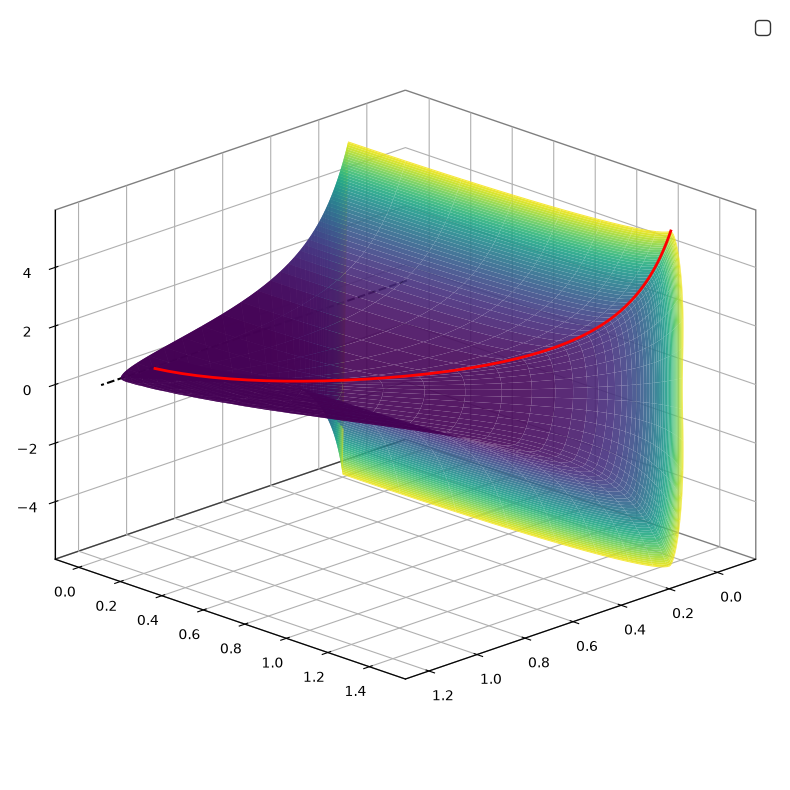

In [8]:
idx = [1,2,3]
surface_locomotion,faces = get_surface(100,data_switch[2],solver)
norm = colors.Normalize(vmin=faces.min(), vmax=faces.max())
fcolor = cm.viridis(norm(faces))[:-1, :-1]
fig_surface = plt.figure(figsize=(10,10))
ax = fig_surface.add_subplot(1,1,1,projection='3d')
ax.set_proj_type('ortho')
ax.plot_surface(surface_locomotion[:,idx[0]], surface_locomotion[:,idx[1]], surface_locomotion[:,idx[2]],facecolors=fcolor,shade=False, edgecolor='none', alpha=0.9)
ax.plot(surface_locomotion[:,idx[0],solver.N_F],surface_locomotion[:,idx[1],solver.N_F],surface_locomotion[:,idx[2],solver.N_F],zorder=10,linewidth = 2, color='red')
x_min,x_max = ax.get_xlim()
ax.plot([x_min,x_max],[0,0],[0,0],'k--')
prettify3D(ax,fgColor='black',bgColor='white')
ax.set_box_aspect((4,4,3))
ax.view_init(elev=20, azim=45, roll=0)# 20 160
plt.show()

In [9]:
def plot_traj(ax,traj,c,lw=0.5):
    ax.plot(traj[1,:],traj[2,:],traj[3,:], linewidth=lw,color=c)

def plot_generator(ax,branch,c,lw,STEP_SIZE,IDX,linestyle='-',d=1,plot_TP=False):
    traj = np.array(branch)
    idx = 0
    idx_TP = []
    for i in range(traj.shape[0] -1):
        if np.linalg.norm(traj[i+1,:] - traj[i,:]) > 2*STEP_SIZE:
            idx = i
        if plot_TP and i>20 and i<traj.shape[0]-20 and np.linalg.det(solver.compute_Jz(traj[i+1,:10],traj[i+1,10])) * np.linalg.det(solver.compute_Jz(traj[i,:10],traj[i,10]))<0:
            idx_TP.append(i)

    if traj[-1,3] > 1e-2 or traj[0,3] > 1e-2:
        ax.plot(traj[:idx+1,IDX[0]],d*traj[:idx+1,IDX[1]],d*traj[:idx+1,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx+1:,IDX[0]],d*traj[idx+1:,IDX[1]],d*traj[idx+1:,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx,IDX[0]],d*traj[idx,IDX[1]],d*traj[idx,IDX[2]],marker='o' if np.abs(traj[idx,3])<1e-2 else 'x',ms=10,color='#fe7f2d')
        ax.plot(traj[-1,IDX[0]],d*traj[-1,IDX[1]],d*traj[-1,IDX[2]],marker='o' if np.abs(traj[-1,3])<1e-2 else 'x',ms=10,color='#fe7f2d')
        for i in idx_TP:
            ax.plot(traj[i,IDX[0]],d*traj[i,IDX[1]],d*traj[i,IDX[2]],marker='d' ,ms=10,color='#fe7f2d')

    elif traj[-1,3] < -1e-2 or traj[0,3] < -1e-2:
        ax.plot(traj[:idx,IDX[0]],-d*traj[:idx,IDX[1]],-d*traj[:idx,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx+1:,IDX[0]],-d*traj[idx+1:,IDX[1]],-d*traj[idx+1:,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx,IDX[0]],-d*traj[idx,IDX[1]],-d*traj[idx,IDX[2]],marker='o' if np.abs(traj[idx,3])<1e-2 else 'x',ms=10,color='#fe7f2d')
        ax.plot(traj[-1,IDX[0]],-d*traj[-1,IDX[1]],-d*traj[-1,IDX[2]],marker='o' if np.abs(traj[-1,3])<1e-2 else 'x',ms=10,color='#fe7f2d')
        for i in idx_TP:
            ax.plot(traj[i,IDX[0]],-d*traj[i,IDX[1]],-d*traj[i,IDX[2]],marker='d' ,ms=10,color='#fe7f2d')



/tmp/ipykernel_118043/1689435179.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  frame = ax.legend(fontsize=fontsize,labelcolor=fgColor).get_frame()


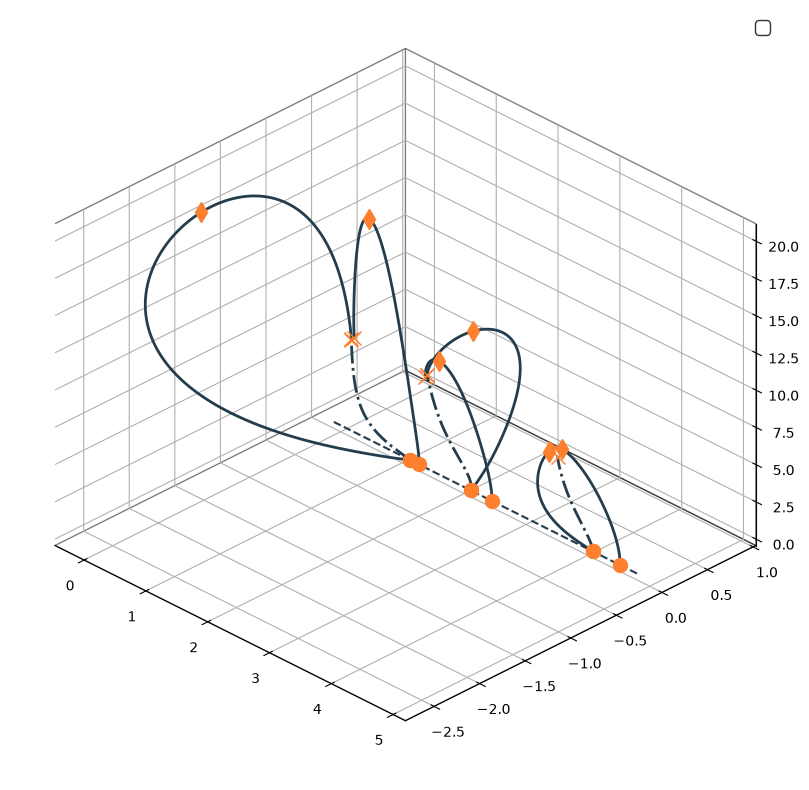

In [ ]:
fig_generator = plt.figure(figsize=(10,10))
ax = fig_generator.add_subplot(1,1,1,projection='3d')
ax.set_proj_type('ortho')
for M in [data_locomotion[i] for i in [2,4,6,8,10,12]]:
    plot_generator(ax,M,'#233d4d',2,0.01,idx,plot_TP=True)
for M in [data_switch[i] for i in [2,4,6]]:
    plot_generator(ax,M,'#233d4d',2,0.01,idx,linestyle='-.',plot_TP=True)
x_min,x_max = ax.get_xlim()
ax.plot([x_min,x_max],[0,0],[0,0],'--',zorder=0,color='#233d4d')
prettify3D(ax,fgColor='black',bgColor='white')
ax.view_init(elev=30, azim=-45, roll=0)
plt.show()

In [19]:
def interpolate_trajectory(traj,tf,fps):
    times = np.linspace(0,tf,traj.shape[1])
    N_frames = int(tf*fps)
    T = np.linspace(0,tf,N_frames)
    xh = np.zeros((traj.shape[0],N_frames))
    i_ = 0
    for i in range(N_frames):
        while T[i] > times[i_+1]:
            i_+=1
        alpha = (T[i] - times[i_])/(times[i_+1]-times[i_])
        xh[:,i] = (1-alpha) * traj[:,i_] + alpha * traj[:,i_+1] 
    return xh

def clean_step(u,fps):
    full_traj = traj(solver,u)[:,:-1]
    xf1 = interpolate_trajectory(full_traj[:,:solver.N_F-1],solver.N_F*u[6]/solver.W,fps)
    xs = interpolate_trajectory(full_traj[:,solver.N_F:solver.N_F+solver.N_S-1],solver.N_S*u[7]/solver.W,fps)
    xf2 = interpolate_trajectory(full_traj[:,solver.N_F+solver.N_S:],solver.N_F*u[8]/solver.W,fps)
    xh = np.hstack([xf1,xs,xf2])
    ah = xh[2,:]
    rh = np.hstack([np.ones(xf1.shape[1],),np.sqrt(xs[0,:]**2 + xs[1,:]**2),np.ones(xf2.shape[1],)])
    return xh,rh,ah

def key_frames(u,fps):
    full_traj = traj(solver,u)
    xf1 = interpolate_trajectory(full_traj[:,:solver.N_F-1],solver.N_F*u[6]/solver.W,fps)
    xs = interpolate_trajectory(full_traj[:,solver.N_F:solver.N_F+solver.N_S-1],solver.N_S*u[7]/solver.W,fps)
    xf2 = interpolate_trajectory(full_traj[:,solver.N_F+solver.N_S:],solver.N_F*u[8]/solver.W,fps)[:,:-1]
    x_frames = np.vstack([xf1[:,0],xf1[:,xf1.shape[1]//2],xs[:,0],xs[:,xs.shape[1]//2],xs[:,-1],xf2[:,xf2.shape[1]//2],xf2[:,-1]])
    r_frames = np.hstack([1,1,1,np.sqrt(xs[0,xs.shape[1]//2]**2 + xs[1,xs.shape[1]//2]**2),1,1,1])
    a_frames = x_frames[:,2]
    return x_frames.T,r_frames, a_frames


def clean_trajectory(u,fps):
    xh1,rh,ah = clean_step(u,fps)
    xh2 = xh1.copy()
    xh3 = xh2.copy()
    xh2[0,:] += xh1[0,-1] - xh2[0,0]
    xh3[0,:] += xh2[0,-1] - xh3[0,0]
    xh = np.hstack([xh1[:,:-1],xh2[:,:-1],xh3])
    rh = np.hstack([rh[:-1],rh[:-1],rh])
    ah = xh[2,:]
    return xh,rh,ah


(6, 7)


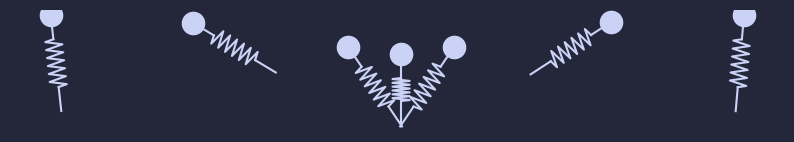

In [31]:

bgColor = '#24273a'
mainColor = '#cad3f5'

def frame(ax,i,xh,ah,rh):
    radial = np.array([-np.sin(ah[i]), np.cos(ah[i])])
    x0 = np.array([xh[0,i], xh[1,i]])
    x1 = x0 - 0.25*radial
    x2 = x0 - ( rh[i] - 0.25) * radial
    x3 = x0 - rh[i] * radial
    ax.plot([xh[0,i]], [xh[1,i]],c=mainColor,marker='o',ms=16)
    X, Y = spring(
        np.array([xh[0,i],xh[1,i]]) - 0.25 * radial,
        np.array([xh[0,i],xh[1,i]]) - ( rh[i] - 0.25) * radial,
        12,
        0.18,
    )
    ax.plot(X, Y,c=mainColor)
    ax.plot([x0[0],x1[0]],[x0[1],x1[1]],c=mainColor)
    ax.plot([x2[0],x3[0]],[x2[1],x3[1]],c=mainColor)



xh,rh,ah = key_frames(data_locomotion[4][1000],60)
print(xh.shape)
fig_kframes = plt.figure(figsize=(10,10),facecolor=bgColor)
ax = fig_kframes.add_subplot(1,1,1)
ax.set_facecolor(bgColor)
ax.set(xticklabels=[], yticklabels=[])
ax.set_axis_off()
for i in range(xh.shape[1]):
    frame(ax,i,xh,ah,rh)
ax.set_aspect("equal")
plt.show()


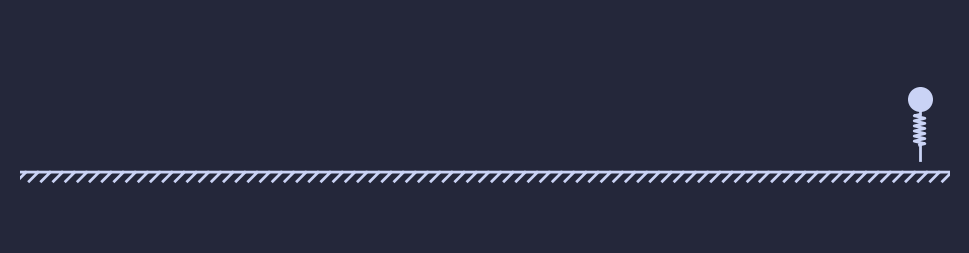

In [ ]:
from matplotlib import animation


xh, rh, ah = clean_trajectory(data_locomotion[4][500],60)


def animate(i):
    radial = np.array([-np.sin(ah[i]), np.cos(ah[i])])
    x0 = np.array([xh[0,i], xh[1,i]])
    x1 = x0 - 0.25*radial
    x2 = x0 - ( rh[i] - 0.25) * radial
    x3 = x0 - rh[i] * radial
    body.set_data([xh[0,i]], [xh[1,i]])
    X, Y = spring(
        np.array([xh[0,i],xh[1,i]]) - 0.25 * radial,
        np.array([xh[0,i],xh[1,i]]) - ( rh[i] - 0.25) * radial,
        12,
        0.18,
    )
    leg.set_data(X, Y)
    upper_leg.set_data([x0[0],x1[0]],[x0[1],x1[1]])
    lower_leg.set_data([x2[0],x3[0]],[x2[1],x3[1]])
    return body,leg,upper_leg,lower_leg


fig = plt.figure(figsize=(6, 5), dpi=200, facecolor=bgColor)
ax = fig.add_subplot(1, 1, 1)
ax.set_xlim(np.min(xh[0,:])-0.5, np.max(xh[0,:])+0.5)
ax.set_ylim(-1, 2.5)
ax.set_aspect("equal")
ax.set_facecolor(bgColor)
ax.set(xticklabels=[], yticklabels=[])
ax.set_axis_off()

(leg,) = ax.plot([], [], lw=1.0, color=mainColor)
(upper_leg,) = ax.plot([], [], lw=1.0, color=mainColor)
(lower_leg,) = ax.plot([], [], lw=1.0, color=mainColor)
(body,) = ax.plot([], [], "o", ms=8, lw=0, color=mainColor)

floor_coor = np.min(xh[0,:])-1
length = np.max(xh[0,:]) - np.min(xh[0,:]) + 2
for i in range(int(length/0.2)):
    ax.plot([floor_coor+i*0.2,floor_coor+i*0.2 + 0.2,floor_coor+i*0.2 + 0.05],[0,0,-0.15], lw=1.0,color=mainColor)




ani = animation.FuncAnimation(fig, animate, range(0,xh.shape[1],1), blit=True,repeat=True)
writervideo = animation.FFMpegWriter(fps=30)
ani.save("output/hopper.mp4", writer=writervideo, savefig_kwargs=dict(facecolor=bgColor))

In [58]:
def plot_generator_alt(ax,branch,c,lw,STEP_SIZE,IDX,linestyle='-',d=1,plot_TP=False):
    traj = np.array(branch)
    idx = 0
    for i in range(traj.shape[0] -1):
        if np.linalg.norm(traj[i+1,:] - traj[i,:]) > 2*STEP_SIZE:
            idx = i

    if traj[-1,3] > 1e-2 or traj[0,3] > 1e-2:
        ax.plot(np.log(traj[:idx+1,IDX[0]]),d*traj[:idx+1,IDX[1]],d*traj[:idx+1,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(np.log(traj[idx+1:,IDX[0]]),d*traj[idx+1:,IDX[1]],d*traj[idx+1:,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)

    elif traj[-1,3] < -1e-2 or traj[0,3] < -1e-2:
        ax.plot(np.log(traj[:idx,IDX[0]]),-d*traj[:idx,IDX[1]],-d*traj[:idx,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(np.log(traj[idx+1:,IDX[0]]),-d*traj[idx+1:,IDX[1]],-d*traj[idx+1:,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)

/tmp/ipykernel_127919/1689435179.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  frame = ax.legend(fontsize=fontsize,labelcolor=fgColor).get_frame()


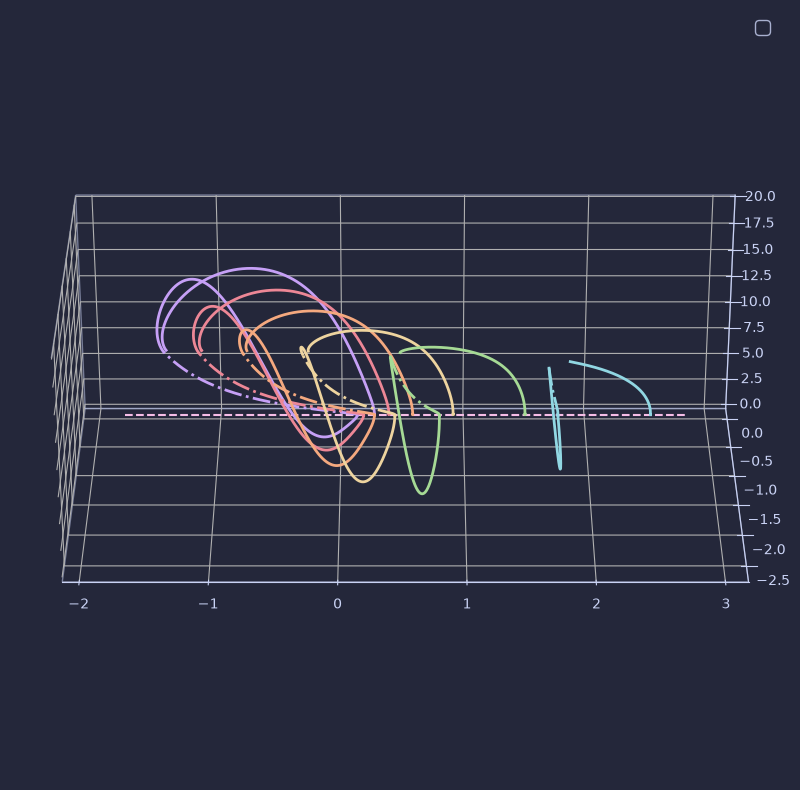

In [63]:

fig_generator = plt.figure(figsize=(10,10),facecolor='#24273a')
ax = fig_generator.add_subplot(1,1,1,projection='3d')
colors = ['#c6a0f6','#ed8796','#f5a97f','#eed49f','#a6da95','#91d7e3']

for w,i in zip([3,2.5,2,1.5,1,0.5],range(6)):

    solver = Continuation_Solver(40,w,1000,0.01,True)
    locomotion0 =  pickle.load(open('data/locomotion{}.pkl'.format(i), 'rb'))
    switch0 =  pickle.load(open('data/switch{}.pkl'.format(i), 'rb'))

    idx = [1,2,3]
    # ax.set_proj_type('ortho')
    for M in locomotion0:
        plot_generator_alt(ax,M,colors[i],2,0.01,idx)
    for M in switch0:
        plot_generator_alt(ax,M,colors[i],2,0.01,idx,linestyle='-.')

x_min,x_max = ax.get_xlim()
ax.plot([x_min,x_max],[0,0],[0,0],'--',zorder=0,color='#f5bde6')
prettify3D(ax)
ax.view_init(elev=30, azim=-90, roll=0)
ax.set_box_aspect((8,4,3))
plt.show()